In [3]:
import pandas as pd
import numpy as np

In [5]:
df_pedidos = pd.read_csv('/content/Ifood/pedidos.csv')
df_cardapio = pd.read_csv('/content/Ifood/cardapio.csv')

## 1. Análise Exploratória de Dados (EDA) ##

In [16]:
# head()
df_pedidos.head()

,ID_Pedido,Data,Cliente_ID,Item,Quantidade,Preco_Unitario,Receita_Item
0,1,2023-11-16,222,Torta de Limao,23.0,12.93,297.39
1,2,2024-05-25,232,Esfiha,NaN,5.87,NaN
2,3,2024-12-20,276,Wrap de Frango,7.0,25.98,181.86
3,4,2024-10-17,198,Batata Frita,NaN,11.62,NaN
4,5,2023-07-06,385,Esfiha,17.0,6.94,117.98


In [17]:
#tail()
df_pedidos.tail()

,ID_Pedido,Data,Cliente_ID,Item,Quantidade,Preco_Unitario,Receita_Item
445,446,2024-02-27,360,Salada Caesar,30.0,27.35,820.50
446,447,2025-05-29,228,Salada Caesar,24.0,29.40,705.60
447,448,2025-08-23,243,Agua Mineral,26.0,4.54,118.04
448,449,2024-08-30,191,Pizza Calabresa,9.0,45.85,412.65
449,450,2025-09-29,122,Yakisoba,8.0,31.72,253.76


In [18]:
#info()
df_pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID_Pedido       450 non-null    int64  
 1   Data            450 non-null    object 
 2   Cliente_ID      450 non-null    int64  
 3   Item            450 non-null    object 
 4   Quantidade      431 non-null    float64
 5   Preco_Unitario  430 non-null    float64
 6   Receita_Item    412 non-null    float64
dtypes: float64(3), int64(2), object(2)
memory usage: 24.7+ KB


In [19]:
#describe()
df_pedidos.describe()

,ID_Pedido,Cliente_ID,Quantidade,Preco_Unitario,Receita_Item
count,450.000000,450.000000,431.000000,430.000000,412.000000
mean,225.500000,245.864444,15.902552,17.856581,286.364879
std,130.048068,88.360604,9.087931,11.601652,270.865944
min,1.000000,100.000000,1.000000,4.090000,4.170000
25%,113.250000,169.000000,8.000000,8.920000,94.050000
50%,225.500000,241.500000,16.000000,13.095000,191.590000
75%,337.750000,325.750000,24.000000,27.402500,391.800000
max,450.000000,399.000000,30.000000,46.070000,1289.960000


## 2. Criação de Novas Colunas (Feature Engineering) ##

In [20]:
# Nova coluna Receita_Item(quantidade × preço unitário)
df_pedidos['Receita_Item'] = df_pedidos['Quantidade'] * df_pedidos['Preco_Unitario']
df_pedidos.head()

,ID_Pedido,Data,Cliente_ID,Item,Quantidade,Preco_Unitario,Receita_Item
0,1,2023-11-16,222,Torta de Limao,23.0,12.93,297.39
1,2,2024-05-25,232,Esfiha,NaN,5.87,NaN
2,3,2024-12-20,276,Wrap de Frango,7.0,25.98,181.86
3,4,2024-10-17,198,Batata Frita,NaN,11.62,NaN
4,5,2023-07-06,385,Esfiha,17.0,6.94,117.98


## 3. Tratamento de Valores Ausentes ##

In [21]:
#Preencha valores ausentes na coluna Quantidade com a média
col_media_qtd = df_pedidos['Quantidade'].mean()
df_pedidos['Quantidade'].fillna(col_media_qtd, inplace=True)
df_pedidos.head()

#Remova linhas com valores nulos na coluna Preco_Unitario
df_pedidos = df_pedidos.dropna(subset=["Preco_Unitario"])
df_pedidos.head()

/tmp/ipykernel_4764/226257005.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pedidos['Quantidade'].fillna(col_media_qtd, inplace=True)


,ID_Pedido,Data,Cliente_ID,Item,Quantidade,Preco_Unitario,Receita_Item
0,1,2023-11-16,222,Torta de Limao,23.000000,12.93,297.39
1,2,2024-05-25,232,Esfiha,15.902552,5.87,NaN
2,3,2024-12-20,276,Wrap de Frango,7.000000,25.98,181.86
3,4,2024-10-17,198,Batata Frita,15.902552,11.62,NaN
4,5,2023-07-06,385,Esfiha,17.000000,6.94,117.98


## 4. Agregações por Item ##

In [22]:
# Agrupe os dados por Item

# Calcule a quantidade total vendida de cada item
df_total_qtd = df_pedidos.groupby('Item')['Quantidade'].sum().reset_index()
print(df_total_qtd)


                   Item  Quantidade
0            Acai 300ml  402.902552
1          Agua Mineral  327.902552
2          Batata Frita  323.902552
3               Brownie  465.902552
4         Cafe Expresso  392.000000
5              Empanada  321.902552
6                Esfiha  364.707657
7            Hamburguer  510.805104
8                Pastel  238.000000
9       Pizza Calabresa  372.805104
10      Pizza Mussarela  349.000000
11    Refrigerante Lata  343.000000
12        Salada Caesar  352.000000
13  Smoothie de Morango  325.902552
14      Sorvete 2 bolas  284.000000
15      Suco de Laranja  263.805104
16        Sushi 8 pecas  378.902552
17       Torta de Limao  249.805104
18       Wrap de Frango  248.000000
19             Yakisoba  318.000000


In [23]:
# Calcule a receita total de cada item
df_total_receita = df_pedidos.groupby('Item')['Receita_Item'].sum().reset_index()
print(df_total_receita)

                   Item  Receita_Item
0            Acai 300ml       6249.76
1          Agua Mineral       1392.59
2          Batata Frita       3785.57
3               Brownie       4440.02
4         Cafe Expresso       2657.71
5              Empanada       2762.86
6                Esfiha       2075.60
7            Hamburguer      10859.02
8                Pastel       2215.46
9       Pizza Calabresa      14545.57
10      Pizza Mussarela      14148.69
11    Refrigerante Lata       2606.87
12        Salada Caesar       9927.96
13  Smoothie de Morango       4511.67
14      Sorvete 2 bolas       3137.76
15      Suco de Laranja       2116.74
16        Sushi 8 pecas      11552.58
17       Torta de Limao       2870.18
18       Wrap de Frango       6611.08
19             Yakisoba       9514.64


In [24]:
#Identifique os top 5 itens mais vendidos
df_total_qtd.sort_values(by='Quantidade', ascending=False).head(5)

,Item,Quantidade
7,Hamburguer,510.805104
3,Brownie,465.902552
0,Acai 300ml,402.902552
4,Cafe Expresso,392.000000
16,Sushi 8 pecas,378.902552


In [25]:
#Identifique os top 5 itens que geraram mais receita
df_total_receita.sort_values(by='Receita_Item', ascending=False).head(5)

,Item,Receita_Item
9,Pizza Calabresa,14545.57
10,Pizza Mussarela,14148.69
16,Sushi 8 pecas,11552.58
7,Hamburguer,10859.02
12,Salada Caesar,9927.96


## 5. Análise Temporal ##

In [28]:
#Converta a coluna Data para o tipo datetime
df_pedidos['Data'] = pd.to_datetime(df_pedidos['Data'])
df_pedidos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 430 entries, 0 to 449
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       430 non-null    int64         
 1   Data            430 non-null    datetime64[ns]
 2   Cliente_ID      430 non-null    int64         
 3   Item            430 non-null    object        
 4   Quantidade      430 non-null    float64       
 5   Preco_Unitario  430 non-null    float64       
 6   Receita_Item    412 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(1)
memory usage: 43.0+ KB


In [29]:
#Extraia o mês de cada pedido
df_pedidos['Mes'] = df_pedidos['Data'].dt.month
df_pedidos.head()

,ID_Pedido,Data,Cliente_ID,Item,Quantidade,Preco_Unitario,Receita_Item,Mes
0,1,2023-11-16,222,Torta de Limao,23.000000,12.93,297.39,11
1,2,2024-05-25,232,Esfiha,15.902552,5.87,NaN,5
2,3,2024-12-20,276,Wrap de Frango,7.000000,25.98,181.86,12
3,4,2024-10-17,198,Batata Frita,15.902552,11.62,NaN,10
4,5,2023-07-06,385,Esfiha,17.000000,6.94,117.98,7


In [32]:
#Calcule a receita total por mês
receita_por_mes = df_pedidos.groupby('Mes')['Receita_Item'].sum().reset_index()
print(receita_por_mes)

    Mes  Receita_Item
0     1       9830.11
1     2      16011.54
2     3       7983.08
3     4       8296.86
4     5      11000.39
5     6       8084.72
6     7       9881.83
7     8      12691.00
8     9      14309.65
9    10       5143.68
10   11       6901.48
11   12       7847.99


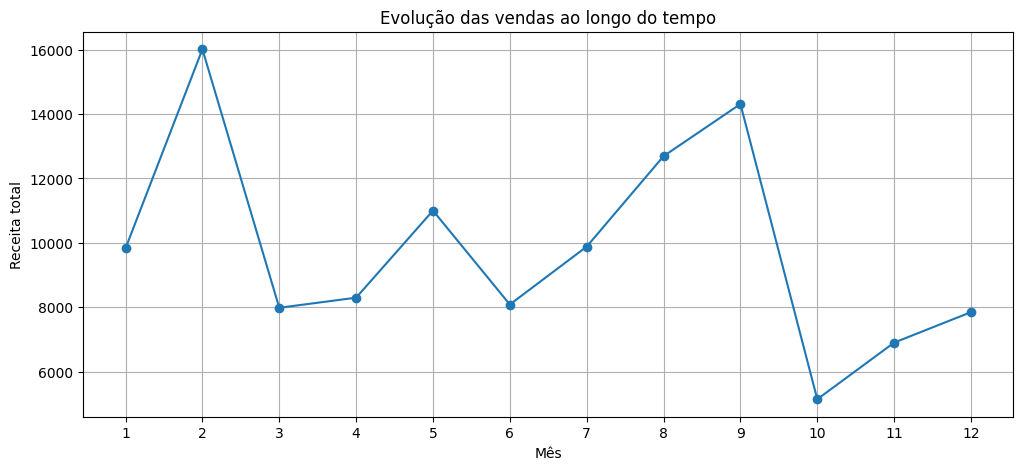

Maior receita: 2.0 - R$ 16011.54
Menor receita: 10.0 - R$ 5143.68


In [35]:
#Analise a evolução das vendas ao longo do tempo
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    receita_por_mes['Mes'].astype(str),
    receita_por_mes['Receita_Item'],
    marker='o')

plt.title('Evolução das vendas ao longo do tempo')
plt.xlabel('Mês')
plt.ylabel('Receita total')

plt.grid()
plt.show()

maior_mes = receita_por_mes.loc[receita_por_mes['Receita_Item'].idxmax()]
menor_mes = receita_por_mes.loc[receita_por_mes['Receita_Item'].idxmin()]

print(f"Maior receita: {maior_mes['Mes']} - R$ {maior_mes['Receita_Item']:.2f}")
print(f"Menor receita: {menor_mes['Mes']} - R$ {menor_mes['Receita_Item']:.2f}")

## 6. Integração de Dados (Merge) ##

In [36]:
#Faça um merge entre pedidos e cardápio usando a coluna
df_pedidos_cardapio = pd.merge(df_pedidos, df_cardapio, on='Item', how='left')
df_pedidos_cardapio.head()

,ID_Pedido,Data,Cliente_ID,Item,Quantidade,Preco_Unitario,Receita_Item,Mes,Categoria,Preco_Base
0,1,2023-11-16,222,Torta de Limao,23.000000,12.93,297.39,11,Doces,12.9
1,2,2024-05-25,232,Esfiha,15.902552,5.87,NaN,5,Salgados,6.5
2,3,2024-12-20,276,Wrap de Frango,7.000000,25.98,181.86,12,Saudaveis,26.5
3,4,2024-10-17,198,Batata Frita,15.902552,11.62,NaN,10,Salgados,12.5
4,5,2023-07-06,385,Esfiha,17.000000,6.94,117.98,7,Salgados,6.5


In [37]:
#Calcule a receita total por Categoria
vendas_por_categoria = df_pedidos_cardapio.groupby('Categoria')['Receita_Item'].sum().reset_index()
print(vendas_por_categoria)

   Categoria  Receita_Item
0    Bebidas       8773.91
1      Doces      21209.39
2   Oriental      21067.22
3   Salgados      50392.77
4  Saudaveis      16539.04


In [39]:
#Identifique qual categoria gera mais receita
vendas_por_categoria.sort_values(by='Receita_Item', ascending=False).head(1)

,Categoria,Receita_Item
3,Salgados,50392.77


## 7. Filtros e Consultas ##

In [40]:
## Filtre pedidos da categoria 'Salgados' com quantidade superior a 10 unidades
pedidos_salgados = df_pedidos_cardapio[(df_pedidos_cardapio['Categoria'] == 'Salgados') & (df_pedidos_cardapio['Quantidade'] > 10)]
print(pedidos_salgados)

     ID_Pedido       Data  Cliente_ID             Item  Quantidade  \
1            2 2024-05-25         232           Esfiha   15.902552   
3            4 2024-10-17         198     Batata Frita   15.902552   
4            5 2023-07-06         385           Esfiha   17.000000   
5            6 2023-02-04         260         Empanada   16.000000   
14          15 2023-02-03         103     Batata Frita   14.000000   
..         ...        ...         ...              ...         ...   
404        423 2023-02-05         252  Pizza Calabresa   16.000000   
409        428 2023-07-11         278           Pastel   18.000000   
415        434 2024-07-17         249           Esfiha   26.000000   
422        442 2023-01-02         261           Esfiha   15.902552   
424        444 2024-04-16         133           Esfiha   27.000000   

     Preco_Unitario  Receita_Item  Mes Categoria  Preco_Base  
1              5.87           NaN    5  Salgados         6.5  
3             11.62           NaN

## 8. KPIs e Análise Estatística com NumPy ##

In [46]:
# Receita Total: soma de toda a receita gerada
receita_total_vendas = df_pedidos_cardapio['Receita_Item'].sum()
print('Receita total: ', receita_total_vendas)

# Total de Itens Vendidos: soma de todas as quantidades vendidas
total_itens_vendidos = df_pedidos_cardapio['Quantidade'].sum()
print('Total de itens vendidos: ', total_itens_vendidos)

# Ticket Médio: receita total dividida pelo número de pedidos
ticket_medio = receita_total_vendas / len(df_pedidos_cardapio)
print('Ticket médio: ', ticket_medio)

Receita total:  117982.33000000002
Total de itens vendidos:  6833.245939675175
Ticket médio:  274.37751162790704


## Desafio Extra (opcional) ##

In [49]:
## Calcule percentis (25%, 50% e 75%) para Preco_Unitario e Quantidade usando funções do NumPy
percentis_preco = np.percentile(
    df_pedidos['Preco_Unitario'],
    [25, 50, 75]
)

percentis_quantidade = np.percentile(
    df_pedidos['Quantidade'],
    [25, 50, 75]
)

print("Percentis do preço:", percentis_preco)
print("Percentis da quantidade:", percentis_quantidade)

Percentis do preço: [ 8.92   13.095  27.4025]
Percentis da quantidade: [ 8. 16. 24.]
